<!-- @format -->

# Adult Income Prediction - Deep Learning Pipeline

Xây dựng pipeline Deep Learning hoàn chỉnh cho bài toán phân loại thu nhập trên tập dữ liệu Adult Census.

**Pipeline gồm các bước:**

1. Tổng quan dữ liệu
2. Tiền xử lí dữ liệu
3. Huấn luyện mô hình
4. Đánh giá & so sánh tổng hợp


<!-- @format -->

## 1. Tổng quan dữ liệu

Phần này tóm tắt nhanh đặc trưng dữ liệu, phân phối target và các đặc trưng quan trọng nhất, giúp định hướng cho pipeline deep learning.


In [39]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import modules.eda as eda
import modules.deep_learning as dl

url = "https://raw.githubusercontent.com/Hanne2202/ml-group10-data/main/adult.csv"
df = eda.load_data(url)

Dataset shape: (48842, 15)
   age  workclass  fnlwgt     education  educational-num      marital-status  \
0   25    Private  226802          11th                7       Never-married   
1   38    Private   89814       HS-grad                9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm               12  Married-civ-spouse   
3   44    Private  160323  Some-college               10  Married-civ-spouse   
4   18          ?  103497  Some-college               10       Never-married   

          occupation relationship   race  gender  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                  ?    Own-child  White  Female             0             0   

   hours-pe

In [40]:
# Tổng quan nhanh dữ liệu
eda.dataset_overview(df)
num_cols, cat_cols = eda.get_column_types(df)

=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB

=== Numerical Summary ===
                age       

In [41]:
# Kiểm tra missing value và giá trị bất thường
eda.check_missing_values(df)
eda.inspect_categorical_values(df, cat_cols)

=== Missing values (NaN) ===
age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

=== '?' count per column ===
age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

=== '?' percentage per column (%) ===
age                0.00
workclass          5.73
fnlwgt             0.00
education          0.00
educational-num    0.00
marital-status     0.00
occupation         5.75
relationship       0.00
race     

<!-- @format -->

**Nhận xét:** Một số cột phân loại có giá trị '?' thay cho missing value. Cần chuẩn hóa về NaN trước khi xử lý tiếp.


Unique values: ['<=50K' '>50K']

Class counts:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Class percentages (%):
income
<=50K    76.07
>50K     23.93
Name: proportion, dtype: float64


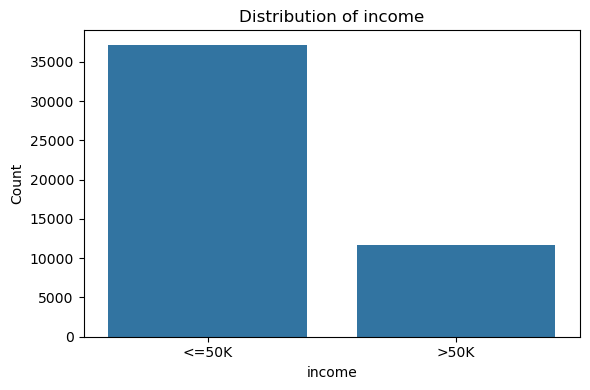

In [42]:
# Phân phối biến mục tiêu (income)
eda.plot_target_distribution(df, target_col='income')

<!-- @format -->

**Nhận xét:** Dữ liệu có mất cân bằng nhẹ giữa hai lớp thu nhập (>50K và <=50K), cần lưu ý khi đánh giá mô hình. Nhóm dự định sẽ sử dụng phương pháp SMOTE để cân bằng lại số lượng của 2 lớp này giúp tránh overfitting đối với người có income >50k.



=== education by income (proportion) ===
income        <=50K   >50K
education                 
10th          0.937  0.063
11th          0.949  0.051
12th          0.927  0.073
1st-4th       0.968  0.032
5th-6th       0.947  0.053
7th-8th       0.935  0.065
9th           0.946  0.054
Assoc-acdm    0.742  0.258
Assoc-voc     0.747  0.253
Bachelors     0.587  0.413
Doctorate     0.274  0.726
HS-grad       0.841  0.159
Masters       0.451  0.549
Preschool     0.988  0.012
Prof-school   0.260  0.740
Some-college  0.810  0.190


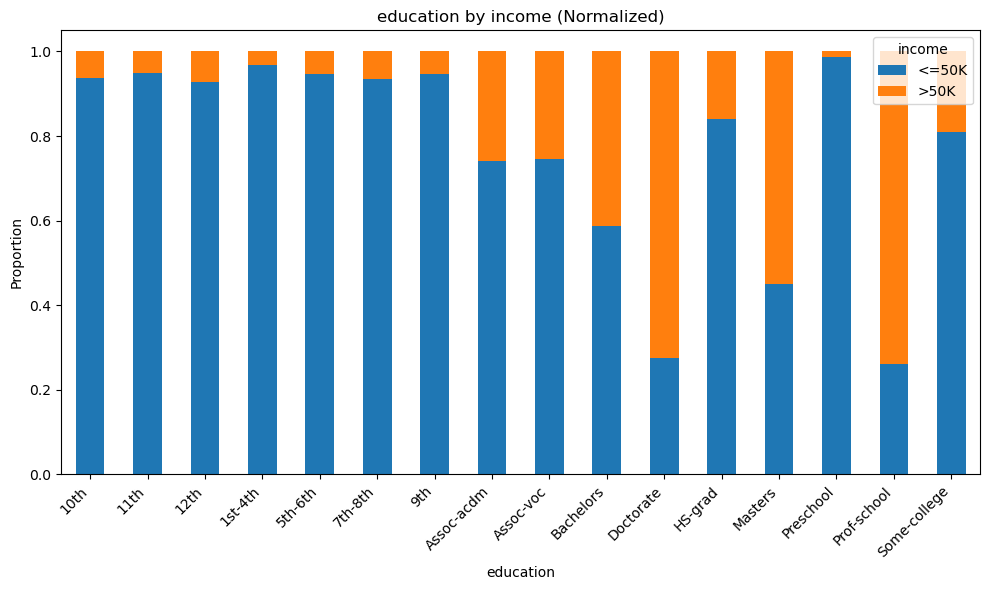


=== occupation by income (proportion) ===
income             <=50K   >50K
occupation                     
?                  0.906  0.094
Adm-clerical       0.863  0.137
Armed-Forces       0.667  0.333
Craft-repair       0.774  0.226
Exec-managerial    0.522  0.478
Farming-fishing    0.884  0.116
Handlers-cleaners  0.933  0.067
Machine-op-inspct  0.877  0.123
Other-service      0.959  0.041
Priv-house-serv    0.988  0.012
Prof-specialty     0.549  0.451
Protective-serv    0.687  0.313
Sales              0.732  0.268
Tech-support       0.710  0.290
Transport-moving   0.796  0.204


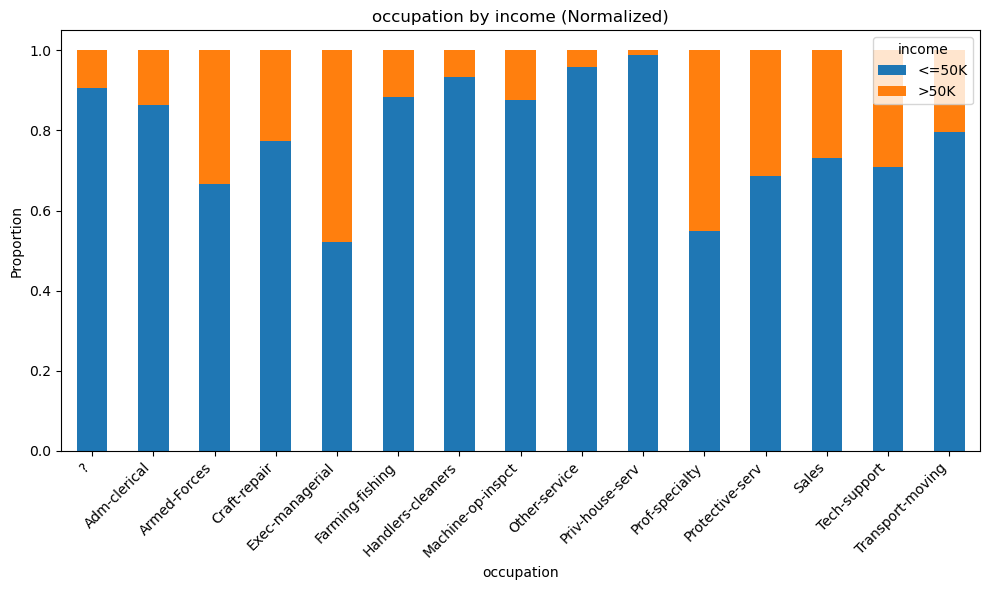


=== marital-status by income (proportion) ===
income                 <=50K   >50K
marital-status                     
Divorced               0.899  0.101
Married-AF-spouse      0.622  0.378
Married-civ-spouse     0.554  0.446
Married-spouse-absent  0.908  0.092
Never-married          0.955  0.045
Separated              0.935  0.065
Widowed                0.916  0.084


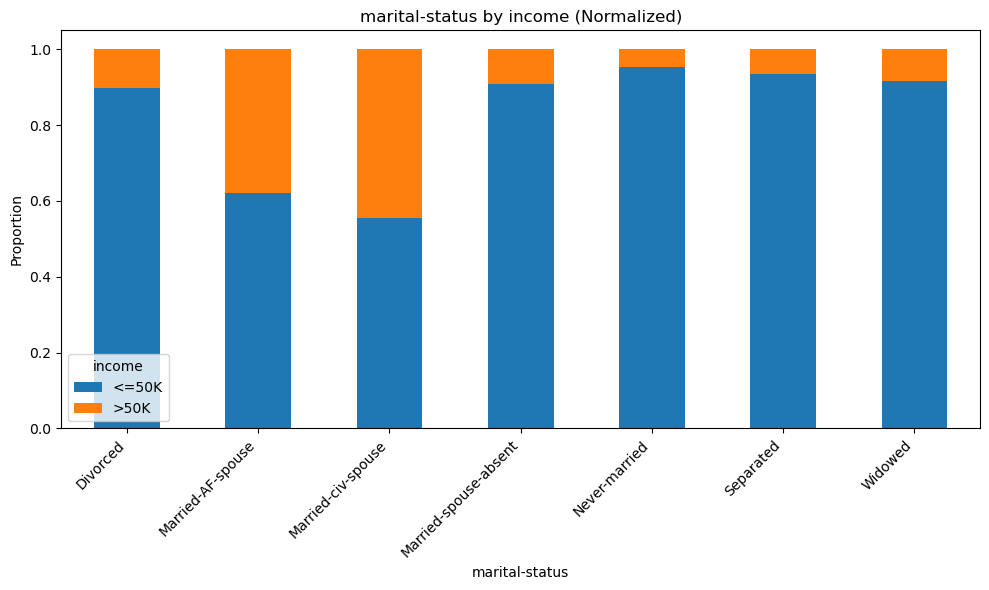

In [43]:
# Phân tích nhanh một số biến phân loại tiêu biểu
top_cat = ['education', 'occupation', 'marital-status']
eda.plot_categorical_by_target(df, top_cat, target_col='income')

<!-- @format -->

**Nhận xét:** Một số biến phân loại như education, occupation, marital-status có sự khác biệt rõ rệt giữa hai nhóm thu nhập.


                age  hours-per-week  educational-num
count  48842.000000    48842.000000     48842.000000
mean      38.643585       40.422382        10.078089
std       13.710510       12.391444         2.570973
min       17.000000        1.000000         1.000000
25%       28.000000       40.000000         9.000000
50%       37.000000       40.000000        10.000000
75%       48.000000       45.000000        12.000000
max       90.000000       99.000000        16.000000


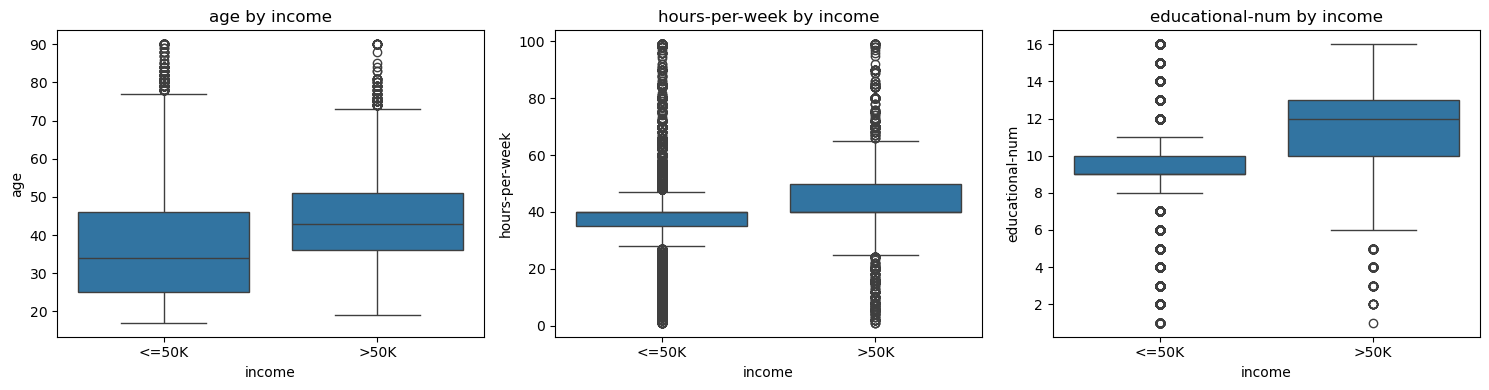

In [44]:
# Phân tích nhanh các biến số quan trọng
num_cols_sel = ['age', 'hours-per-week', 'educational-num']
eda.plot_numerical_by_target(df, num_cols_sel, target_col='income')

<!-- @format -->

**Nhận xét:** Các biến số như age, hours-per-week, educational-num đều có sự khác biệt phân phối giữa hai nhóm thu nhập.


=== capital-gain ===
count    48842.000000
mean      1079.067626
std       7452.019058
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-gain, dtype: float64

Zero values : 44807 (91.74%)
Non-zero    : 4035 (8.26%)

Proportion of non-zero capital-gain by income:
capital-gain  False  True 
income                    
<=50K         0.958  0.042
>50K          0.787  0.213


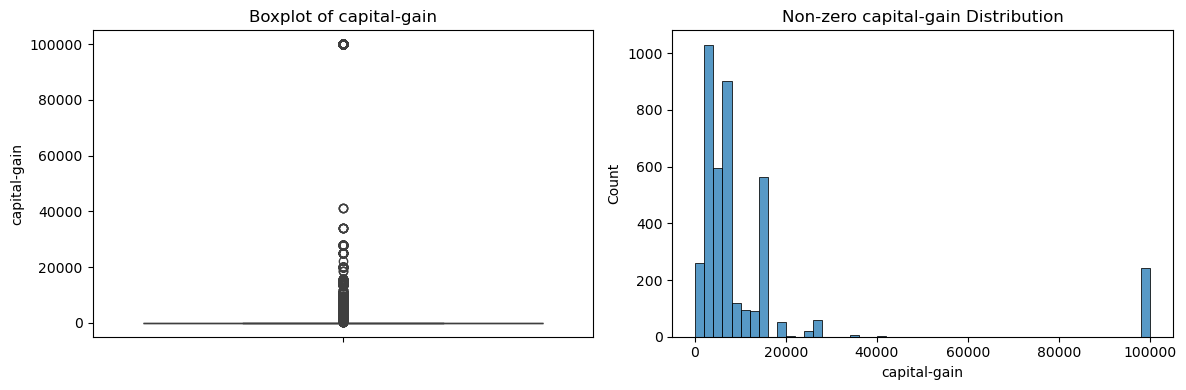

=== capital-loss ===
count    48842.000000
mean        87.502314
std        403.004552
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       4356.000000
Name: capital-loss, dtype: float64

Zero values : 46560 (95.33%)
Non-zero    : 2282 (4.67%)

Proportion of non-zero capital-loss by income:
capital-loss  False  True 
income                    
<=50K         0.969  0.031
>50K          0.902  0.098


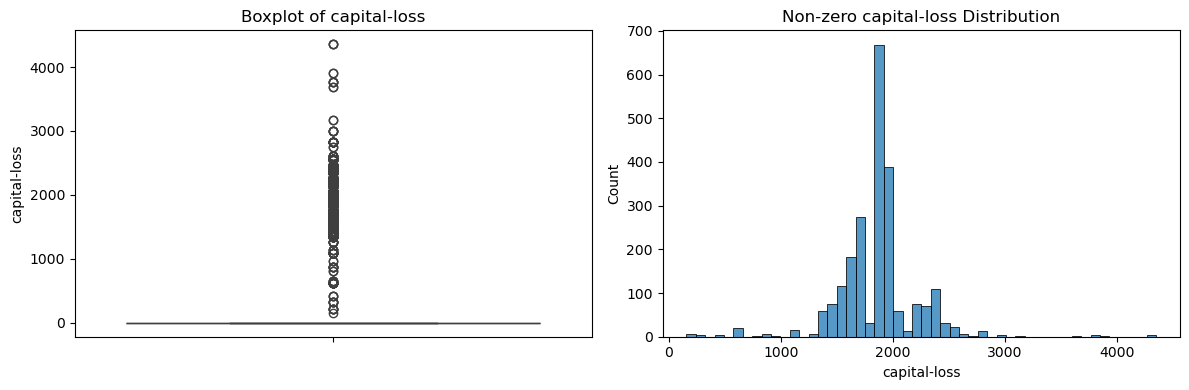

In [45]:
# Phân tích phân phối và ý nghĩa của capital-gain, capital-loss
eda.analyze_capital_feature(df, 'capital-gain', target_col='income')
eda.analyze_capital_feature(df, 'capital-loss', target_col='income')

<!-- @format -->

**Nhận xét:** Cả hai biến capital-gain và capital-loss đều có phân phối rất lệch, nhiều giá trị 0, nhưng tỷ lệ giá trị khác 0 ở nhóm >50K cao hơn đáng kể. Đây là đặc trưng hữu ích cho mô hình.


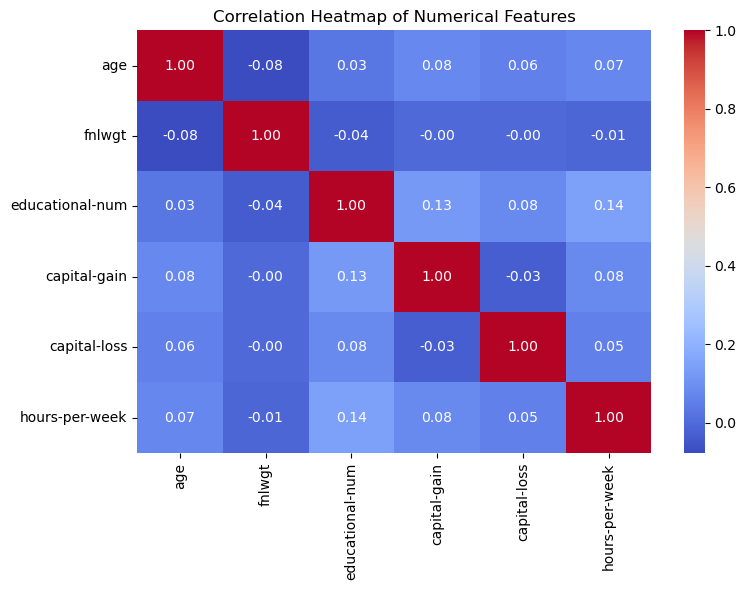

In [46]:
# Heatmap tương quan các biến số
eda.plot_correlation_heatmap(df, num_cols)

<!-- @format -->

**Nhận xét:** Các biến số không có cặp nào tương quan quá cao, có thể giữ lại hầu hết cho mô hình.


In [47]:
# Kiểm tra trùng lặp thông tin education & educational-num
eda.check_education_redundancy(df)

Mapping between education and educational-num:
       education educational-num
0           10th             [6]
1           11th             [7]
2           12th             [8]
3        1st-4th             [2]
4        5th-6th             [3]
5        7th-8th             [4]
6            9th             [5]
7     Assoc-acdm            [12]
8      Assoc-voc            [11]
9      Bachelors            [13]
10     Doctorate            [16]
11       HS-grad             [9]
12       Masters            [14]
13     Preschool             [1]
14   Prof-school            [15]
15  Some-college            [10]


<!-- @format -->

**Nhận xét:** Hai cột education và educational-num gần như mang cùng thông tin, có thể cân nhắc chỉ giữ lại một trong hai khi xây dựng mô hình.


<!-- @format -->

# 2. Tiền xử lí dữ liệu


<!-- @format -->

## 2.1. Import preprocessing module


In [48]:
import modules.preprocessing as prep

from modules.preprocessing import (
    drop_columns,
    drop_missing_values,
    map_target_variable,
    apply_ohe,
    scale_numeric,
    split_data,
    apply_smote,
)

<!-- @format -->

## 2.2. Làm sạch dữ liệu

Các bước:

1. **Xoá cột dư thừa**: `education` (trùng thông tin với `educational-num`) và `fnlwgt` (trọng số thống kê, không liên quan phân loại).
2. **Xử lý giá trị `?`**: thay bằng `NaN` rồi xoá các hàng thiếu.
3. **Mã hoá biến mục tiêu**: `<=50K` → 0, `>50K` → 1.


In [49]:
df_clean = df.copy()

# 1. Xoá cột dư thừa
df_clean = drop_columns(df_clean, columns=['education', 'fnlwgt'])

# 2. Xử lý missing value ('?' → NaN → drop row)
df_clean = drop_missing_values(df_clean)

# 3. Mã hoá biến mục tiêu
df_clean = map_target_variable(df_clean, target_col='income')

print(f"\nKích thước sau làm sạch: {df_clean.shape}")
df_clean.head()

Dropped columns: ['education', 'fnlwgt']
Dropped rows with missing values: 3620
Mapped target variable 'income' to binary (0 / 1).

Kích thước sau làm sạch: (45222, 13)


,age,workclass,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
5,34,Private,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,0


<!-- @format -->

## 2.3. Xác định loại đặc trưng


In [50]:
TARGET_COL = 'income'

num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

# Bỏ target khỏi danh sách (nếu có)
if TARGET_COL in num_cols: num_cols.remove(TARGET_COL)
if TARGET_COL in cat_cols: cat_cols.remove(TARGET_COL)

print(f"Numerical features ({len(num_cols)}): {num_cols}")
print(f"Categorical features ({len(cat_cols)}): {cat_cols}")

Numerical features (5): ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features (7): ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']


<!-- @format -->

## 2.4. Chia dữ liệu Train / Val / Test

Split **trước** khi encode & scale để tránh data leakage.
Tỉ lệ: **70% train – 10% val – 20% test** (stratify theo `income`).


In [51]:
X_train_raw, X_val_raw, X_test_raw, y_train, y_val, y_test = split_data(
    df_clean,
    target_col=TARGET_COL,
    test_size=0.2,
    val_size=0.1,
    random_state=42,
)

Split → Train: 31654, Val: 4523, Test: 9045
  Class dist (train) >50K: 24.8%


<!-- @format -->

## 2.5. One-Hot Encoding (categorical)

Fit `OneHotEncoder` **chỉ trên train**, sau đó transform val/test bằng cùng encoder đó.


In [52]:
X_train_ohe, ohe_encoder = apply_ohe(X_train_raw, cat_cols)
X_val_ohe, _= apply_ohe(X_val_raw,   cat_cols, encoder=ohe_encoder)
X_test_ohe, _= apply_ohe(X_test_raw,  cat_cols, encoder=ohe_encoder)

print(f"\nShape sau OHE  →  train: {X_train_ohe.shape} | val: {X_val_ohe.shape} | test: {X_test_ohe.shape}")

Applied OHE on 7 columns → 82 new columns.
Applied OHE on 7 columns → 82 new columns.
Applied OHE on 7 columns → 82 new columns.

Shape sau OHE  →  train: (31654, 87) | val: (4523, 87) | test: (9045, 87)


<!-- @format -->

## 2.6. Chuẩn hoá đặc trưng số (StandardScaler)

Fit `StandardScaler` **chỉ trên train**, transform val/test.


In [53]:
X_train_sc, scaler = scale_numeric(X_train_ohe, num_cols)
X_val_sc,   _      = scale_numeric(X_val_ohe,   num_cols, scaler=scaler)
X_test_sc,  _      = scale_numeric(X_test_ohe,  num_cols, scaler=scaler)

Scaled 5 numeric columns: ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Scaled 5 numeric columns: ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Scaled 5 numeric columns: ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']


<!-- @format -->

## 2.7. Cân bằng lớp bằng SMOTE (chỉ dùng cho Logistic Regression)

Dữ liệu có **mất cân bằng ~24%** ở lớp `>50K`.
SMOTE sinh các mẫu tổng hợp cho lớp thiểu số **chỉ trên tập train** để tránh data leakage.

> **Lưu ý về phạm vi áp dụng**: SMOTE ở bước này chỉ được sử dụng cho **Logistic Regression baseline**.
> Các mô hình MLP sẽ dùng `pos_weight` trong `BCEWithLogitsLoss` thay thế (xem Section 4).
>
> **Hạn chế của SMOTE sau OHE**: SMOTE hoạt động bằng nội suy tuyến tính giữa các mẫu.
> Khi áp dụng trên cột One-Hot Encoded (chỉ nhận 0/1), kết quả nội suy có thể tạo ra giá trị thập phân
> (e.g. 0.3, 0.7) không có ý nghĩa ngữ nghĩa cho biến phân loại.
> Phương án chuẩn hơn là **SMOTE-NC** hoặc áp dụng oversampling trước bước OHE.
>
> Val/test **không được** áp dụng SMOTE – phải giữ nguyên phân phối thực tế.


In [54]:
X_train_sm, y_train_sm = apply_smote(
    X_train_sc,
    y_train,
    sampling_strategy='auto',   # cân bằng 50/50
    k_neighbors=5,
    random_state=42,
)

SMOTE applied (strategy='auto', k=5)
  Before → {0: 23809, 1: 7845}  |  total=31654
  After  → {0: 23809, 1: 23809}   |  total=47618
  Class dist after SMOTE >50K: 50.0%


<!-- @format -->

## 2.8. Tóm tắt kết quả preprocessing


In [55]:
import pandas as pd

summary = pd.DataFrame({
    'Split': [
        'Train – gốc (dùng cho MLP)',
        'Train – sau SMOTE (chỉ dùng cho LR baseline)',
        'Val   (giữ nguyên)',
        'Test  (giữ nguyên)',
    ],
    'Samples': [
        len(X_train_sc), len(X_train_sm), len(X_val_sc), len(X_test_sc)
    ],
    'Features': [
        X_train_sc.shape[1], X_train_sm.shape[1], X_val_sc.shape[1], X_test_sc.shape[1]
    ],
    'Class >50K': [
        f"{y_train.mean():.1%}",
        f"{y_train_sm.mean():.1%}",
        f"{y_val.mean():.1%}",
        f"{y_test.mean():.1%}",
    ],
})
print(summary.to_string(index=False))
print(f"\nEncoding artifacts saved:")
print(f"  ohe_encoder : {type(ohe_encoder).__name__}")
print(f"  scaler      : {type(scaler).__name__}")

                                       Split  Samples  Features Class >50K
                  Train – gốc (dùng cho MLP)    31654        87      24.8%
Train – sau SMOTE (chỉ dùng cho LR baseline)    47618        87      50.0%
                          Val   (giữ nguyên)     4523        87      24.8%
                          Test  (giữ nguyên)     9045        87      24.8%

Encoding artifacts saved:
  ohe_encoder : OneHotEncoder
  scaler      : StandardScaler


<!-- @format -->

# 3. Logistic Regression (Baseline)

Logistic Regression được dùng làm **baseline** để so sánh với MLP sau này.

**Lý do chọn làm baseline:**

- Đơn giản, huấn luyện nhanh, dễ giải thích
- Hiệu quả tốt với dữ liệu đã được scale và OHE
- Kết quả của nó là ngưỡng tối thiểu mà MLP cần vượt qua


<!-- @format -->

## 3.1. Huấn luyện Logistic Regression


In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score,
)
import matplotlib.pyplot as plt
import numpy as np

# Dùng X_train_sm (sau SMOTE) để train
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs',
)
lr_model.fit(X_train_sm, y_train_sm)
print("Logistic Regression trained.")

Logistic Regression trained.


<!-- @format -->

## 3.2. Đánh giá trên Val set


In [57]:
y_val_pred_lr  = lr_model.predict(X_val_sc)
y_val_proba_lr = lr_model.predict_proba(X_val_sc)[:, 1]

print("=== Logistic Regression – Val Set ===")
print(classification_report(y_val, y_val_pred_lr, target_names=['<=50K', '>50K']))

val_metrics_lr = {
    'accuracy' : round(accuracy_score(y_val,  y_val_pred_lr),  4),
    'precision': round(precision_score(y_val, y_val_pred_lr),  4),
    'recall'   : round(recall_score(y_val,    y_val_pred_lr),  4),
    'f1_score' : round(f1_score(y_val,        y_val_pred_lr),  4),
    'roc_auc'  : round(roc_auc_score(y_val,   y_val_proba_lr), 4),
}
print("Val metrics:", val_metrics_lr)

=== Logistic Regression – Val Set ===
              precision    recall  f1-score   support

       <=50K       0.94      0.79      0.86      3402
        >50K       0.57      0.85      0.68      1121

    accuracy                           0.80      4523
   macro avg       0.76      0.82      0.77      4523
weighted avg       0.85      0.80      0.82      4523

Val metrics: {'accuracy': 0.8046, 'precision': 0.5709, 'recall': 0.851, 'f1_score': 0.6834, 'roc_auc': 0.9056}


<!-- @format -->

## 3.3. Đánh giá trên Test set


=== Logistic Regression – Test Set ===
              precision    recall  f1-score   support

       <=50K       0.94      0.79      0.86      6803
        >50K       0.57      0.84      0.68      2242

    accuracy                           0.80      9045
   macro avg       0.76      0.82      0.77      9045
weighted avg       0.85      0.80      0.81      9045

Test metrics: {'accuracy': 0.8043, 'precision': 0.5712, 'recall': 0.8448, 'f1_score': 0.6815, 'roc_auc': 0.9038}


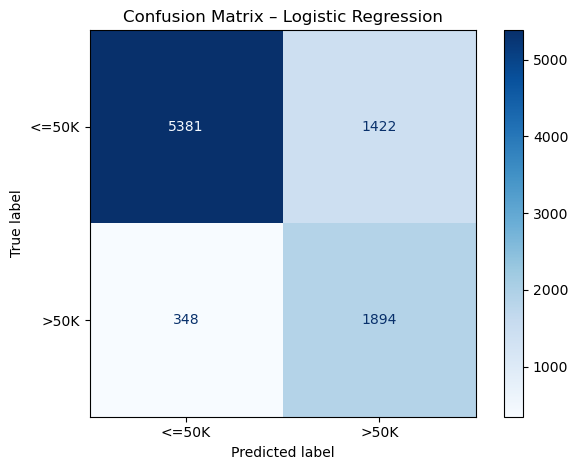

In [58]:
y_test_pred_lr  = lr_model.predict(X_test_sc)
y_test_proba_lr = lr_model.predict_proba(X_test_sc)[:, 1]

print("=== Logistic Regression – Test Set ===")
print(classification_report(y_test, y_test_pred_lr, target_names=['<=50K', '>50K']))

test_metrics_lr = {
    'accuracy' : round(accuracy_score(y_test,  y_test_pred_lr),  4),
    'precision': round(precision_score(y_test, y_test_pred_lr),  4),
    'recall'   : round(recall_score(y_test,    y_test_pred_lr),  4),
    'f1_score' : round(f1_score(y_test,        y_test_pred_lr),  4),
    'roc_auc'  : round(roc_auc_score(y_test,   y_test_proba_lr), 4),
}
print("Test metrics:", test_metrics_lr)

# Confusion matrix
cm_lr = confusion_matrix(y_test, y_test_pred_lr)
disp  = ConfusionMatrixDisplay(cm_lr, display_labels=['<=50K', '>50K'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix – Logistic Regression')
plt.tight_layout()
plt.show()

<!-- @format -->

# 4. MLP – Multi-Layer Perceptron

So sánh MLP với Logistic Regression baseline.

**Kiến trúc MLP:**

- Input layer → Hidden layers (BatchNorm → ReLU → Dropout) → Output (1 logit)
- Loss: `BCEWithLogitsLoss` với `pos_weight` để xử lý class imbalance (thay vì SMOTE)
- Optimizer: Adam + ReduceLROnPlateau scheduler
- Early stopping theo `val_loss`

> **Lưu ý về class imbalance:** MLP sử dụng `pos_weight = n_negative / n_positive` trong loss function thay vì SMOTE, vì SMOTE áp dụng sau OHE có thể sinh ra giá trị thập phân cho các cột nhị phân (0/1), làm mất ý nghĩa ngữ nghĩa của one-hot encoding.


<!-- @format -->

## 4.1. Setup device & DataLoaders


In [59]:
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True   # buộc dùng thuật toán xác định
    torch.backends.cudnn.benchmark     = False  # tắt auto-tuning non-deterministic
print(f"Global seed set to {SEED}. CUDA deterministic: {torch.cuda.is_available()}")

Global seed set to 42. CUDA deterministic: True


In [60]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

# MLP dùng dữ liệu KHÔNG SMOTE, class imbalance xử lý qua pos_weight trong loss
# (tránh vấn đề SMOTE tạo giá trị thập phân trên cột OHE nhị phân)
prep_data = {
    'X_train': X_train_sc.values.astype('float32'),
    'X_val'  : X_val_sc.values.astype('float32'),
    'X_test' : X_test_sc.values.astype('float32'),
    'y_train': y_train.values.astype('int64'),
    'y_val'  : y_val.values.astype('int64'),
    'y_test' : y_test.values.astype('int64'),
    'input_dim': X_train_sc.shape[1],
}

train_loader, val_loader, test_loader = dl.create_dataloaders(prep_data, batch_size=256)

Using device: cuda
DataLoaders created  |  batch_size=256
  Train batches: 124  |  Val: 18  |  Test: 36


<!-- @format -->

## 4.2. MLP cơ bản [256, 128, 64]


In [61]:
model_mlp = dl.MLP(
    input_dim=prep_data['input_dim'],
    hidden_dims=[256, 128, 64],
    dropout=0.4,
)
print(model_mlp)
print(f"Tổng số tham số: {sum(p.numel() for p in model_mlp.parameters()):,}")

MLP(
  (net): Sequential(
    (linear_0): Linear(in_features=87, out_features=256, bias=True)
    (bn_0): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu_0): ReLU()
    (drop_0): Dropout(p=0.4, inplace=False)
    (linear_1): Linear(in_features=256, out_features=128, bias=True)
    (bn_1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu_1): ReLU()
    (drop_1): Dropout(p=0.4, inplace=False)
    (linear_2): Linear(in_features=128, out_features=64, bias=True)
    (bn_2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu_2): ReLU()
    (drop_2): Dropout(p=0.4, inplace=False)
    (output): Linear(in_features=64, out_features=1, bias=True)
  )
)
Tổng số tham số: 64,641


In [62]:
history_mlp = dl.train_model(
    model_mlp,
    train_loader,
    val_loader,
    epochs=100,
    lr=1e-3,
    weight_decay=1e-3,
    patience=20,
    device=device,
    use_pos_weight=True,
)

BCE pos_weight (w1/w0): 3.0349
Training on cuda  |  epochs=100  |  lr=0.001  |  patience=20
----------------------------------------------------------------------
Epoch   1/100  |  train_loss=0.6644  train_acc=0.7615  |  val_loss=0.5709  val_acc=0.7913 *
Epoch   2/100  |  train_loss=0.5896  train_acc=0.7964  |  val_loss=0.5643  val_acc=0.7957 *
Epoch   3/100  |  train_loss=0.5815  train_acc=0.8000  |  val_loss=0.5604  val_acc=0.8121 *
Epoch   4/100  |  train_loss=0.5771  train_acc=0.8035  |  val_loss=0.5564  val_acc=0.8039 *
Epoch   5/100  |  train_loss=0.5743  train_acc=0.8030  |  val_loss=0.5535  val_acc=0.8085 *
Epoch   8/100  |  train_loss=0.5681  train_acc=0.8056  |  val_loss=0.5532  val_acc=0.8116 *
Epoch   9/100  |  train_loss=0.5651  train_acc=0.8103  |  val_loss=0.5525  val_acc=0.8105 *
Epoch  10/100  |  train_loss=0.5608  train_acc=0.8095  |  val_loss=0.5570  val_acc=0.8030
Epoch  12/100  |  train_loss=0.5640  train_acc=0.8095  |  val_loss=0.5522  val_acc=0.8158 *
Epoch  15/1

<!-- @format -->

## 4.3. Learning Curves


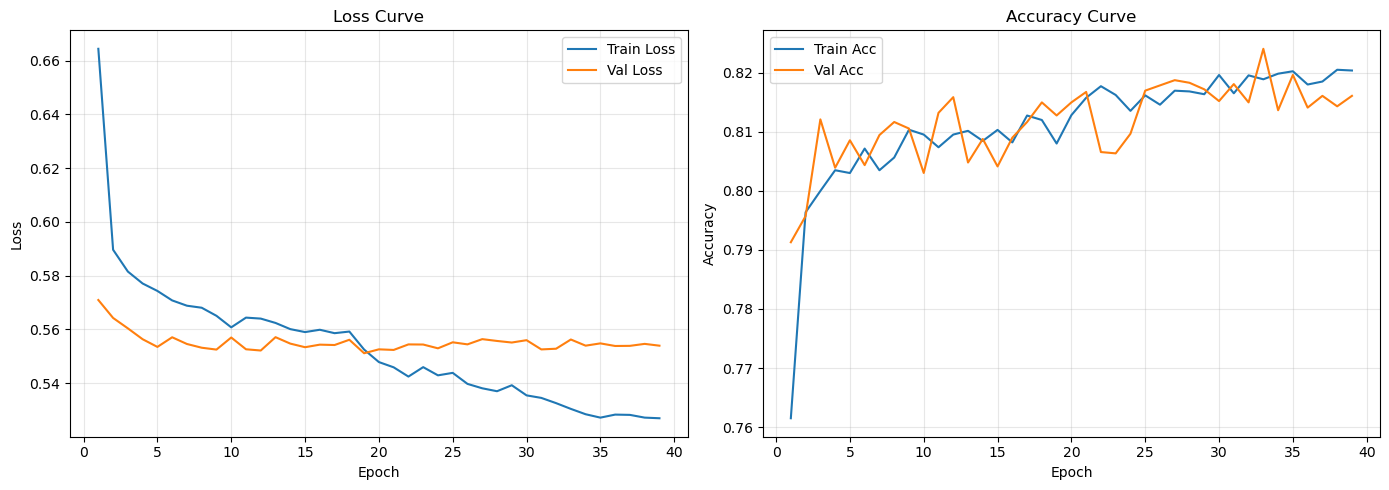

In [63]:
dl.plot_learning_curves(history_mlp)

<!-- @format -->

**Nhận xét:** Model học tốt trên tập train nhưng không cải thiện trên validation, cho thấy dấu hiệu overfitting nhẹ và cần triển khai các phương pháp khác


<!-- @format -->

## 4.4. Đánh giá MLP trên Test set


=== Classification Report ===
              precision    recall  f1-score   support

       <=50K       0.94      0.79      0.86      6803
        >50K       0.57      0.86      0.69      2242

    accuracy                           0.81      9045
   macro avg       0.76      0.82      0.77      9045
weighted avg       0.85      0.81      0.82      9045

Summary: {'accuracy': 0.8056, 'precision': 0.5721, 'recall': 0.8568, 'f1_score': 0.6861}


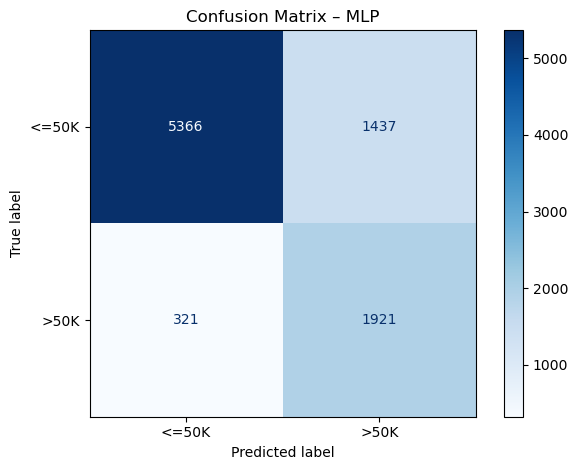

In [64]:
test_metrics_mlp, y_true_mlp, y_pred_mlp, y_proba_mlp = dl.evaluate_model(
    model_mlp, test_loader, device=device
)

<!-- @format -->

## 4.5. So sánh Logistic Regression vs MLP


In [65]:
import pandas as pd

compare = pd.DataFrame([
    {
        'Model'    : 'Logistic Regression (baseline)',
        'Accuracy' : test_metrics_lr['accuracy'],
        'Precision': test_metrics_lr['precision'],
        'Recall'   : test_metrics_lr['recall'],
        'F1-Score' : test_metrics_lr['f1_score'],
        'ROC-AUC'  : test_metrics_lr['roc_auc'],
    },
    {
        'Model'    : 'MLP [256, 128, 64]',
        'Accuracy' : test_metrics_mlp['accuracy'],
        'Precision': test_metrics_mlp['precision'],
        'Recall'   : test_metrics_mlp['recall'],
        'F1-Score' : test_metrics_mlp['f1_score'],
        'ROC-AUC'  : round(roc_auc_score(y_true_mlp, y_proba_mlp), 4),
    },
])

compare = compare.set_index('Model')
print(compare.to_string())
compare.style.highlight_max(axis=0, color='lightgreen')

                                Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                                         
Logistic Regression (baseline)    0.8043     0.5712  0.8448    0.6815   0.9038
MLP [256, 128, 64]                0.8056     0.5721  0.8568    0.6861   0.9090


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression (baseline),0.804300,0.571200,0.844800,0.681500,0.903800
"MLP [256, 128, 64]",0.805600,0.572100,0.856800,0.686100,0.909000


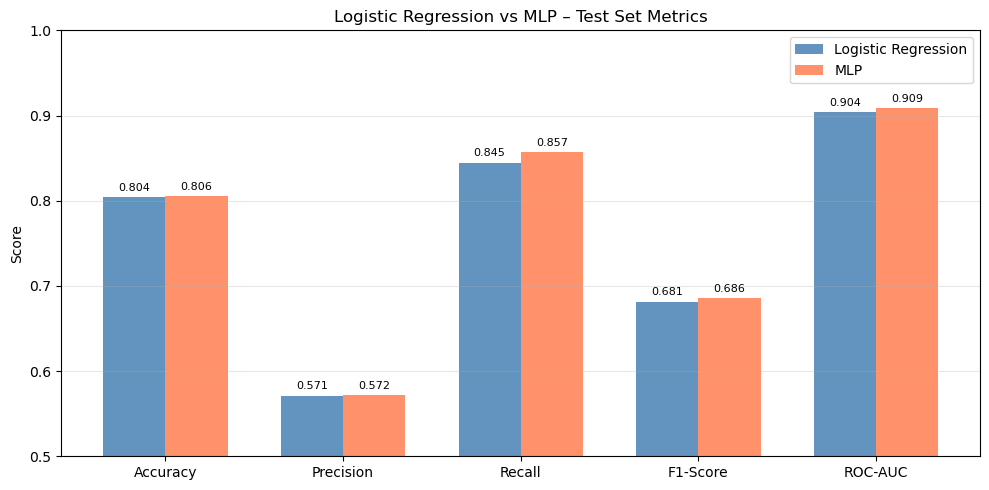

In [66]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, compare.loc['Logistic Regression (baseline)', metrics_to_plot],
               width, label='Logistic Regression', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, compare.loc['MLP [256, 128, 64]', metrics_to_plot],
               width, label='MLP', color='coral', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('Logistic Regression vs MLP – Test Set Metrics')
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<!-- @format -->

**Nhận xét:** MLP cơ bản mà nhóm đề ra không mang lại cải thiện so với Logistic Regression, thậm chí còn kém nhẹ. Do đó nhóm chuyển sang tối ưu siêu tham số với Optuna.


<!-- @format -->

# 5. Tối ưu hoá Siêu tham số với Optuna (Automatic Hyperparameter Tuning)

Tiếp theo, ta sử dụng thư viện **Optuna** đã được đóng gói trong file `modules/tuning_mlp.py` để thực hiện quá trình Auto-ML. Công cụ này sẽ tự động chạy thử nhiều cấu hình tham số khác nhau (số lớp, số node, lr, dropout, batch_size...) và tìm ra tập hợp trả về điểm **F1-Score** trên tập Validation cao nhất.


In [67]:
import modules.tuning as tune

print("Bắt đầu tìm kiếm tham số tối ưu bằng Optuna...")
# Dùng bộ dữ liệu KHÔNG có SMOTE nhưng đã chuẩn hoá
# class imbalance xử lý qua pos_weight trong loss (như MLP cơ bản)
prep_tuned = {
    'X_train': X_train_sc.values.astype('float32'),
    'X_val'  : X_val_sc.values.astype('float32'),
    'X_test' : X_test_sc.values.astype('float32'),
    'y_train': y_train.values.astype('int64'),
    'y_val'  : y_val.values.astype('int64'),
    'y_test' : y_test.values.astype('int64'),
    'input_dim': X_train_sc.shape[1],
}
train_loader_tuned, val_loader_tuned, test_loader_tuned = dl.create_dataloaders(prep_tuned, batch_size=256)

# Mock study: lưu lại best_params từ lần chạy Optuna thực (30 trials, ~7-10 phút)
# trên máy nhóm để tái sử dụng mà không cần chạy lại.
# Bỏ comment cell bên dưới và thay study_mlp = run_optuna_search(...) để chạy lại từ đầu.
def get_mock_study_mlp():
    class MockStudy:
        def __init__(self, best_params):
            self.best_params = best_params
            self.best_value = 0.7049062049062049  # best val F1 đạt được
    return MockStudy({
        "n_layers": 3,
        "hidden_dim_0": 320,
        "hidden_dim_1": 448,
        "hidden_dim_2": 32,
        "dropout": 0.35,
        "lr": 0.00015193253929678293,
        "weight_decay": 3.0308702059789768e-05,
        "batch_size": 512,
        "optimizer": "AdamW"
    })
study_mlp = get_mock_study_mlp()

Bắt đầu tìm kiếm tham số tối ưu bằng Optuna...
DataLoaders created  |  batch_size=256
  Train batches: 124  |  Val: 18  |  Test: 36


<!-- @format -->

### QUÁ TRÌNH NÀY TỐN TRUNG BÌNH 7-10 PHÚT NÊN ĐƯỢC COMMENT LẠI VÀ CHẠY BẰNG DỮ LIỆU HARDCODE TỪ CÁC LẦN CHẠY TRÊN MÁY SINH VIÊN ĐỂ TIẾT KIỆM THỜI GIAN, BỎ COMMENT PHÍA DƯỚI ĐỂ XEM ĐƯỢC QUÁ TRÌNH CHẠY


In [68]:
# study_mlp = tune.run_optuna_search(
#     prep=prep_tuned, 
#     n_trials=30,  # Có thể tăng số lượng trial lên 50-100 nếu có nhiều thời gian (Tạm để 30 để chạy tốc hành)
#     epochs=50, 
#     patience=10, 
#     device=device
# )

# # Trực quan hoá lịch sử tìm kiếm và độ quan trọng của các tham số
# tune.plot_optuna_results(study_mlp)

Training best MLP: hidden_dims=[320, 448, 32], dropout=0.35
  lr=1.52e-04, weight_decay=3.03e-05, batch=512, opt=AdamW
DataLoaders created  |  batch_size=512
  Train batches: 62  |  Val: 9  |  Test: 18
Training on cuda  |  epochs=100  |  patience=15
----------------------------------------------------------------------
Epoch   1/100  |  train_loss=0.8035  train_acc=0.6688  |  val_loss=0.6928  val_acc=0.7367 *
Epoch   2/100  |  train_loss=0.6950  train_acc=0.7384  |  val_loss=0.6486  val_acc=0.7544 *
Epoch   3/100  |  train_loss=0.6635  train_acc=0.7537  |  val_loss=0.6289  val_acc=0.7634 *
Epoch   4/100  |  train_loss=0.6469  train_acc=0.7610  |  val_loss=0.6140  val_acc=0.7661 *
Epoch   5/100  |  train_loss=0.6297  train_acc=0.7673  |  val_loss=0.6009  val_acc=0.7798 *
Epoch   6/100  |  train_loss=0.6166  train_acc=0.7771  |  val_loss=0.5889  val_acc=0.7809 *
Epoch   7/100  |  train_loss=0.6079  train_acc=0.7808  |  val_loss=0.5832  val_acc=0.7844 *
Epoch   8/100  |  train_loss=0.5977

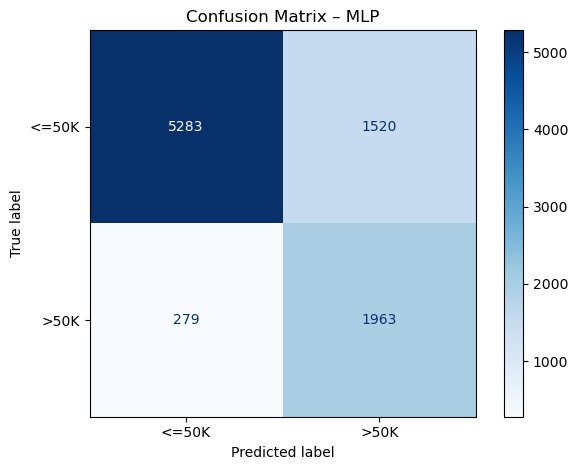

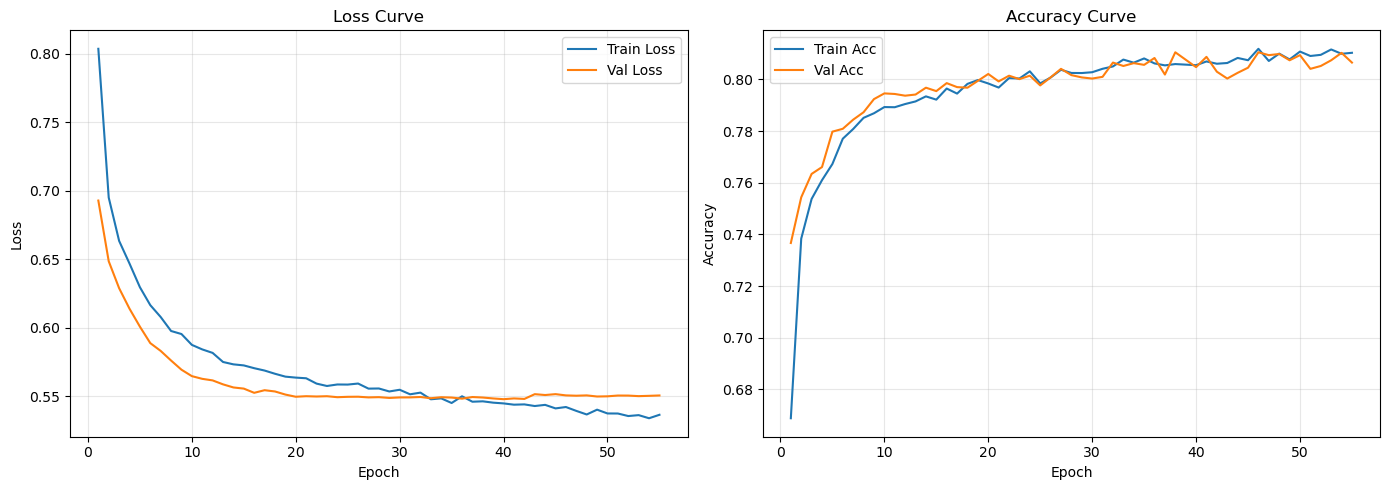

In [69]:
# 5.1. Huấn luyện lại và đánh giá mô hình bằng tham số đỉnh nhất (Best params)
best_model_optuna, best_history_optuna, best_metrics_optuna = tune.train_best_optuna_model(
    study=study_mlp,
    prep=prep_tuned,
    epochs=100,
    patience=15,
    device=device
)

# Vẽ lại learning curve của best model
dl.plot_learning_curves(best_history_optuna)

<!-- @format -->

**Nhận xét:** Model với các siêu tham số mới này đã thể hiện việc học có cải thiện tốt hơn trên tập dữ liệu validation so với các tham số cơ bản ban đầu nhóm đề ra.


<!-- @format -->

## 5.2. So sánh Logistic Regression vs MLP Optuna Best


=== Classification Report ===
              precision    recall  f1-score   support

       <=50K       0.95      0.78      0.85      6803
        >50K       0.56      0.88      0.69      2242

    accuracy                           0.80      9045
   macro avg       0.76      0.83      0.77      9045
weighted avg       0.85      0.80      0.81      9045

Summary: {'accuracy': 0.8011, 'precision': 0.5636, 'recall': 0.8756, 'f1_score': 0.6858}


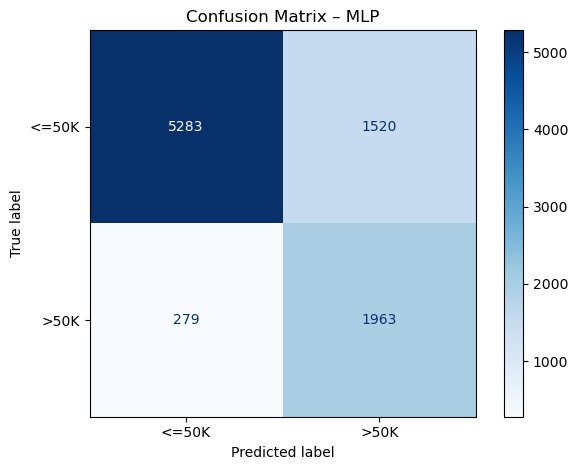

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression (baseline),0.804300,0.571200,0.844800,0.681500,0.903800
MLP (Optuna Best),0.801100,0.563600,0.875600,0.685800,0.909900


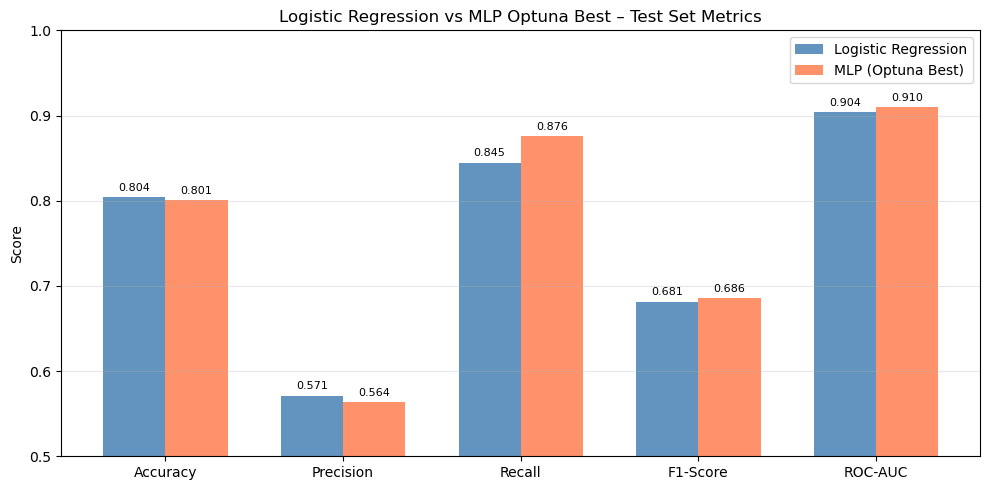

In [70]:
# Lấy dự đoán từ mô hình tốt nhất của Optuna để tính ROC-AUC
_, y_true_optuna, _, y_proba_optuna = dl.evaluate_model(best_model_optuna, test_loader_tuned, device=device)

compare_optuna = pd.DataFrame([
    {
        'Model'    : 'Logistic Regression (baseline)',
        'Accuracy' : test_metrics_lr['accuracy'],
        'Precision': test_metrics_lr['precision'],
        'Recall'   : test_metrics_lr['recall'],
        'F1-Score' : test_metrics_lr['f1_score'],
        'ROC-AUC'  : test_metrics_lr['roc_auc'],
    },
    {
        'Model'    : 'MLP (Optuna Best)',
        'Accuracy' : best_metrics_optuna['accuracy'],
        'Precision': best_metrics_optuna['precision'],
        'Recall'   : best_metrics_optuna['recall'],
        'F1-Score' : best_metrics_optuna['f1_score'],
        'ROC-AUC'  : round(roc_auc_score(y_true_optuna, y_proba_optuna), 4),
    },
])

compare_optuna = compare_optuna.set_index('Model')
display(compare_optuna.style.highlight_max(axis=0, color='lightgreen'))

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, compare_optuna.loc['Logistic Regression (baseline)', metrics_to_plot],
               width, label='Logistic Regression', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, compare_optuna.loc['MLP (Optuna Best)', metrics_to_plot],
               width, label='MLP (Optuna Best)', color='coral', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('Logistic Regression vs MLP Optuna Best – Test Set Metrics')
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<!-- @format -->

**Nhận xét:** MLP đã cải thiện hơn so với Logistic Regression, tuy không nhiều với F1-Score và ROC-AUC nhưng cũng cho thấy hiệu quả trong việc áp dụng Optuna. Tiếp theo nhóm sẽ thử nghiệm trên model TabNet để xem hiệu quả.


<!-- @format -->

# 6. TabNet Model (Attentive Interpretable Tabular Learning)

Sử dụng kiến trúc TabNet được tối ưu hóa đặc biệt cho dữ liệu dạng bảng.
Nhóm quyết định **KHÔNG sử dụng SMOTE** cho TabNet; class imbalance được xử lý qua `class_weight` nội bộ của TabNet.

**Điểm khác biệt của pipeline TabNet so với MLP:**

- **Integer encoding** thay vì One-Hot Encoding — categorical features giữ dạng số nguyên để TabNet dùng embedding layer nội bộ.
- **Binning** (mặc định bật): cột `age` và `hours-per-week` được chia thành 4 bucket và chuyển thành biến categorical. Điều này giúp TabNet xử lý tốt hơn các biến số có phân phối lệch nhưng làm thay đổi không gian đặc trưng so với pipeline MLP.
- **val_size=0.1** được truyền tường minh để đồng nhất tỉ lệ split với MLP.


In [71]:
# Chuẩn bị Data gốc cho TabNet
# Lưu ý: dùng prep.preprocess_for_tabnet (từ modules/preprocessing.py)
print("--- Chuẩn bị Data gốc cho TabNet ---")
prep_tabnet = prep.preprocess_for_tabnet(
    df_clean,
    target_col='income',
    val_size=0.1,   # Đồng nhất với split của MLP (val_size mặc định là 0.2)
    random_state=42
)

print("\nShape của dữ liệu train TabNet:", prep_tabnet['X_train'].shape)

--- Chuẩn bị Data gốc cho TabNet ---
Rare category grouping (threshold=0.01):
  workclass: 1 rare → 'Other'  (kept 7 categories)
  marital-status: 1 rare → 'Other'  (kept 7 categories)
  occupation: 2 rare → 'Other'  (kept 13 categories)
  race: 2 rare → 'Other'  (kept 4 categories)
  native-country: 39 rare → 'Other'  (kept 3 categories)
  Total rare categories grouped: 45
Encoding mode: TabNet integer categorical + internal embeddings
Num features : 3 | Cat features: 9
cat_idxs     : [3, 4, 5, 6, 7, 8, 9, 10, 11]
cat_dims     : [8, 8, 14, 7, 5, 3, 4, 5, 4]

Shape của dữ liệu train TabNet: (32559, 12)


In [72]:
# 2. Đào tạo mô hình TabNet

print("\n--- Bắt đầu Training TabNet ---")
tabnet_model = dl.train_tabnet_model(
    prep=prep_tabnet,
    n_d=32,               # Kích thước lớp quyết định
    n_a=32,               # Kích thước lớp chú ý
    n_steps=3,            # Số chặng Attention
    gamma=1.3,
    lr=2e-2,
    max_epochs=100,       
    patience=15,          # Dừng sớm nếu sau 15 epoch val loss không giảm
    batch_size=512,
    virtual_batch_size=128,
    device=device
)


--- Bắt đầu Training TabNet ---
TabNet class weights: {0: 0.6647407104940792, 1: 2.017536249845086}


c:\Users\ADMIN\anaconda3\envs\ai_env\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.50602 | val_logloss: 1.11609 |  0:00:03s
epoch 1  | loss: 0.42701 | val_logloss: 0.62187 |  0:00:06s
epoch 2  | loss: 0.40908 | val_logloss: 0.58686 |  0:00:09s
epoch 3  | loss: 0.40249 | val_logloss: 0.45061 |  0:00:12s
epoch 4  | loss: 0.40202 | val_logloss: 0.45145 |  0:00:16s
epoch 5  | loss: 0.39263 | val_logloss: 0.40019 |  0:00:19s
epoch 6  | loss: 0.39443 | val_logloss: 0.41958 |  0:00:22s
epoch 7  | loss: 0.39223 | val_logloss: 0.45111 |  0:00:25s
epoch 8  | loss: 0.39135 | val_logloss: 0.41771 |  0:00:28s
epoch 9  | loss: 0.38263 | val_logloss: 0.38566 |  0:00:31s
epoch 10 | loss: 0.38274 | val_logloss: 0.42664 |  0:00:34s
epoch 11 | loss: 0.3857  | val_logloss: 0.42116 |  0:00:37s
epoch 12 | loss: 0.38912 | val_logloss: 0.39867 |  0:00:40s
epoch 13 | loss: 0.38888 | val_logloss: 0.38344 |  0:00:42s
epoch 14 | loss: 0.3861  | val_logloss: 0.39044 |  0:00:45s
epoch 15 | loss: 0.3863  | val_logloss: 0.37857 |  0:00:48s
epoch 16 | loss: 0.38189 | val_logloss: 

c:\Users\ADMIN\anaconda3\envs\ai_env\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


TabNet training complete. Best epoch: 15


=== Classification Report (TabNet) ===
              precision    recall  f1-score   support

       <=50K       0.93      0.81      0.87      6803
        >50K       0.58      0.82      0.68      2242

    accuracy                           0.81      9045
   macro avg       0.76      0.81      0.77      9045
weighted avg       0.85      0.81      0.82      9045

Summary: {'accuracy': 0.8112, 'precision': 0.5848, 'recall': 0.8211, 'f1_score': 0.6831}


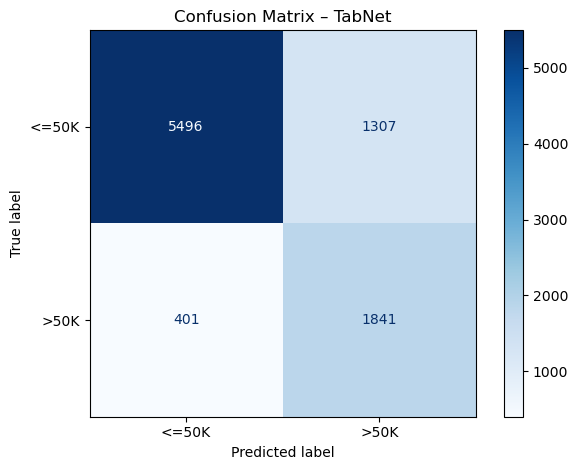

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression (baseline),0.804300,0.571200,0.844800,0.681500,0.903800
MLP (Optuna Best),0.801100,0.563600,0.875600,0.685800,0.909900
TabNet Basic (No SMOTE),0.811200,0.584800,0.821100,0.683100,0.902000


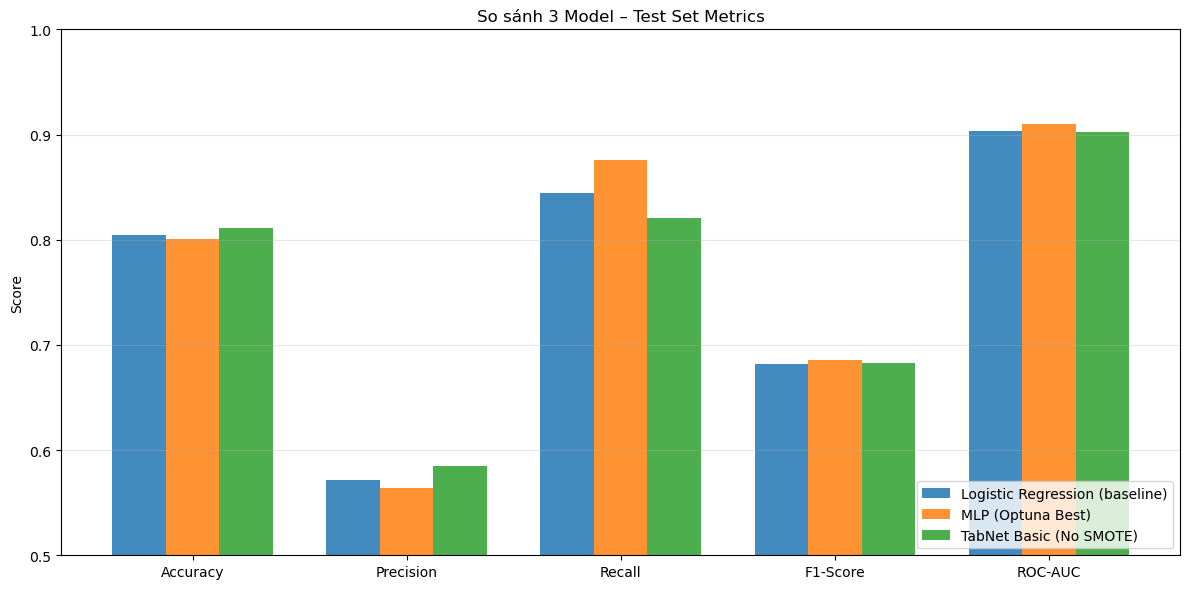

In [73]:
# 3. Đánh giá và So sánh lại với các Baseline trước đó
metrics_tabnet, y_true_tabnet, y_pred_tabnet, y_proba_tabnet = dl.evaluate_tabnet(tabnet_model, prep_tabnet)

compare_all = pd.DataFrame([
    {
        'Model'    : 'Logistic Regression (baseline)',
        'Accuracy' : test_metrics_lr['accuracy'],
        'Precision': test_metrics_lr['precision'],
        'Recall'   : test_metrics_lr['recall'],
        'F1-Score' : test_metrics_lr['f1_score'],
        'ROC-AUC'  : test_metrics_lr['roc_auc'],
    },
    {
        'Model'    : 'MLP (Optuna Best)',
        'Accuracy' : best_metrics_optuna['accuracy'],
        'Precision': best_metrics_optuna['precision'],
        'Recall'   : best_metrics_optuna['recall'],
        'F1-Score' : best_metrics_optuna['f1_score'],
        'ROC-AUC'  : round(roc_auc_score(y_true_optuna, y_proba_optuna), 4),
    },
    {
        'Model'    : 'TabNet Basic (No SMOTE)',
        'Accuracy' : metrics_tabnet['accuracy'],
        'Precision': metrics_tabnet['precision'],
        'Recall'   : metrics_tabnet['recall'],
        'F1-Score' : metrics_tabnet['f1_score'],
        'ROC-AUC'  : round(roc_auc_score(y_true_tabnet, y_proba_tabnet), 4),
    },
])

compare_all = compare_all.set_index('Model')
display(compare_all.style.highlight_max(axis=0, color='lightgreen'))

# Trực quan hoá
fig, ax = plt.subplots(figsize=(12, 6))
width_new = 0.25
for i, model_name in enumerate(compare_all.index):
    ax.bar(x + (i - 1) * width_new, compare_all.loc[model_name, metrics_to_plot],
           width_new, label=model_name, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('So sánh 3 Model – Test Set Metrics')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<!-- @format -->

**Nhận xét:** TabNet với các tham số mà nhóm đưa ra chưa cải thiện được so với MLP, thậm chí còn thấp hơn ở F1-Score. Do đó, nhóm tiếp tục tối ưu siêu tham số của TabNet với Optuna


<!-- @format -->

# 7. Tối ưu hoá Siêu tham số TabNet với Optuna

Chúng ta sẽ sử dụng các hàm đã được gói sẵn trong `modules/tuning_mlp.py` để tìm kiếm siêu tham số và huấn luyện mô hình TabNet tốt nhất. Đặc biệt ở đây còn kèm theo **Cơ chế Pretraining (Self-supervised learning)** tích hợp sẵn.


In [74]:
# 7.1 Mock study TabNet Optuna: lưu lại best_params từ lần chạy thực (10 trials, ~30-40 phút)
# trên máy nhóm để tái sử dụng mà không cần chạy lại.
# Bỏ comment cell bên dưới và thay study_tabnet = run_optuna_search_tabnet(...) để chạy lại từ đầu.
def get_mock_study_tabnet(*args, **kwargs):
    class MockStudy:
        def __init__(self, best_params):
            self.best_params = best_params
            self.best_value = 0.6885694729637235  # best val F1 đạt được
    return MockStudy({
        "width": 8,
        "n_steps": 4,
        "gamma": 1.0137868611216592,
        "lambda_sparse": 0.003924034647132935,
        "lr": 0.007085132090225794,
        "batch_size": 512,
        "virtual_batch_size": 256,
        "pretrain_epochs": 50,
        "pretraining_ratio": 0.6195014675689636
    })
study_tabnet = get_mock_study_tabnet()

<!-- @format -->

### QUÁ TRÌNH NÀY TỐN TRUNG BÌNH 30-40 PHÚT NÊN ĐƯỢC COMMENT LẠI VÀ CHẠY BẰNG DỮ LIỆU HARDCODE TỪ CÁC LẦN CHẠY TRÊN MÁY SINH VIÊN ĐỂ TIẾT KIỆM THỜI GIAN, BỎ COMMENT PHÍA DƯỚI ĐỂ XEM ĐƯỢC QUÁ TRÌNH CHẠY


In [75]:
# study_tabnet = tune.run_optuna_search_tabnet(
#     prep_tabnet=prep_tabnet,
#     n_trials=10, 
#     max_epochs=50,
#     patience=10,
#     device=device,
#     use_pretraining=True # Sử dụng pretrain tích hợp sẵn
# )

c:\Users\ADMIN\anaconda3\envs\ai_env\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 3.35    | val_unsup_loss_numpy: 1.09211003780365|  0:00:04s
epoch 1  | loss: 1.00914 | val_unsup_loss_numpy: 1.0088900327682495|  0:00:09s
epoch 2  | loss: 0.99038 | val_unsup_loss_numpy: 0.9795799851417542|  0:00:14s
epoch 3  | loss: 0.97201 | val_unsup_loss_numpy: 0.9258700013160706|  0:00:19s
epoch 4  | loss: 0.95257 | val_unsup_loss_numpy: 0.8737800121307373|  0:00:24s
epoch 5  | loss: 0.93556 | val_unsup_loss_numpy: 0.825219988822937|  0:00:29s
epoch 6  | loss: 0.90386 | val_unsup_loss_numpy: 0.815090000629425|  0:00:34s
epoch 7  | loss: 0.91302 | val_unsup_loss_numpy: 0.7928799986839294|  0:00:39s
epoch 8  | loss: 0.90053 | val_unsup_loss_numpy: 0.7664399743080139|  0:00:43s
epoch 9  | loss: 0.89061 | val_unsup_loss_numpy: 0.7516400218009949|  0:00:48s
epoch 10 | loss: 0.8987  | val_unsup_loss_numpy: 0.7683799862861633|  0:00:53s
epoch 11 | loss: 0.8932  | val_unsup_loss_numpy: 0.7710899710655212|  0:00:59s
epoch 12 | loss: 0.88928 | val_unsup_loss_numpy: 0.75069

c:\Users\ADMIN\anaconda3\envs\ai_env\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
c:\Users\ADMIN\anaconda3\envs\ai_env\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")
c:\Users\ADMIN\anaconda3\envs\ai_env\lib\site-packages\pytorch_tabnet\abstract_model.py:248: UserWarning: Loading weights from unsupervised pretraining
  warnings.warn("Loading weights from unsupervised pretraining")


epoch 0  | loss: 0.89083 | val_logloss: 0.85329 |  0:00:02s
epoch 1  | loss: 0.42401 | val_logloss: 0.67959 |  0:00:05s
epoch 2  | loss: 0.40951 | val_logloss: 0.50977 |  0:00:08s
epoch 3  | loss: 0.40068 | val_logloss: 0.43806 |  0:00:11s
epoch 4  | loss: 0.39224 | val_logloss: 0.45794 |  0:00:14s
epoch 5  | loss: 0.38816 | val_logloss: 0.41419 |  0:00:16s
epoch 6  | loss: 0.39009 | val_logloss: 0.42365 |  0:00:19s
epoch 7  | loss: 0.38999 | val_logloss: 0.43743 |  0:00:22s
epoch 8  | loss: 0.38503 | val_logloss: 0.42582 |  0:00:26s
epoch 9  | loss: 0.38689 | val_logloss: 0.41314 |  0:00:29s
epoch 10 | loss: 0.38593 | val_logloss: 0.37675 |  0:00:32s
epoch 11 | loss: 0.38219 | val_logloss: 0.43375 |  0:00:38s
epoch 12 | loss: 0.38314 | val_logloss: 0.41189 |  0:00:40s
epoch 13 | loss: 0.37998 | val_logloss: 0.41978 |  0:00:43s
epoch 14 | loss: 0.3769  | val_logloss: 0.3691  |  0:00:46s
epoch 15 | loss: 0.38066 | val_logloss: 0.36413 |  0:00:49s
epoch 16 | loss: 0.3789  | val_logloss: 

c:\Users\ADMIN\anaconda3\envs\ai_env\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


TabNet training complete. Best epoch: 15
=== Classification Report (TabNet) ===
              precision    recall  f1-score   support

       <=50K       0.93      0.81      0.87      6803
        >50K       0.59      0.82      0.68      2242

    accuracy                           0.81      9045
   macro avg       0.76      0.81      0.78      9045
weighted avg       0.85      0.81      0.82      9045

Summary: {'accuracy': 0.8124, 'precision': 0.5874, 'recall': 0.8171, 'f1_score': 0.6835}


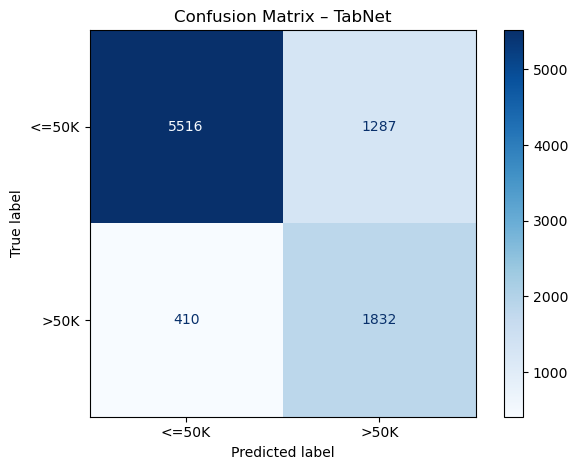

=== Classification Report (TabNet) ===
              precision    recall  f1-score   support

       <=50K       0.93      0.81      0.87      6803
        >50K       0.59      0.82      0.68      2242

    accuracy                           0.81      9045
   macro avg       0.76      0.81      0.78      9045
weighted avg       0.85      0.81      0.82      9045

Summary: {'accuracy': 0.8124, 'precision': 0.5874, 'recall': 0.8171, 'f1_score': 0.6835}


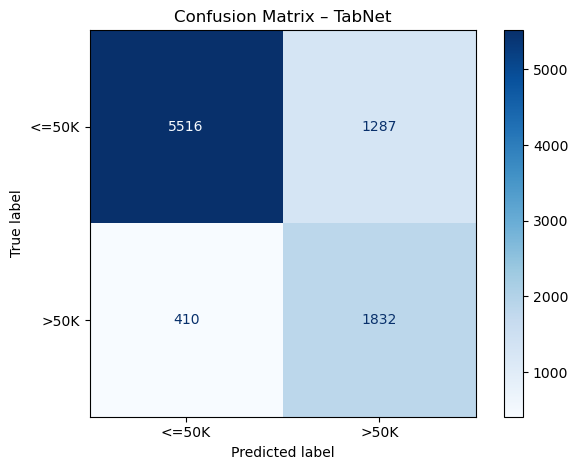

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression (baseline),0.804300,0.571200,0.844800,0.681500,0.903800
MLP (Optuna Best),0.801100,0.563600,0.875600,0.685800,0.909900
TabNet Basic (No SMOTE),0.811200,0.584800,0.821100,0.683100,0.902000
TabNet (Optuna Best),0.812400,0.587400,0.817100,0.683500,0.902900


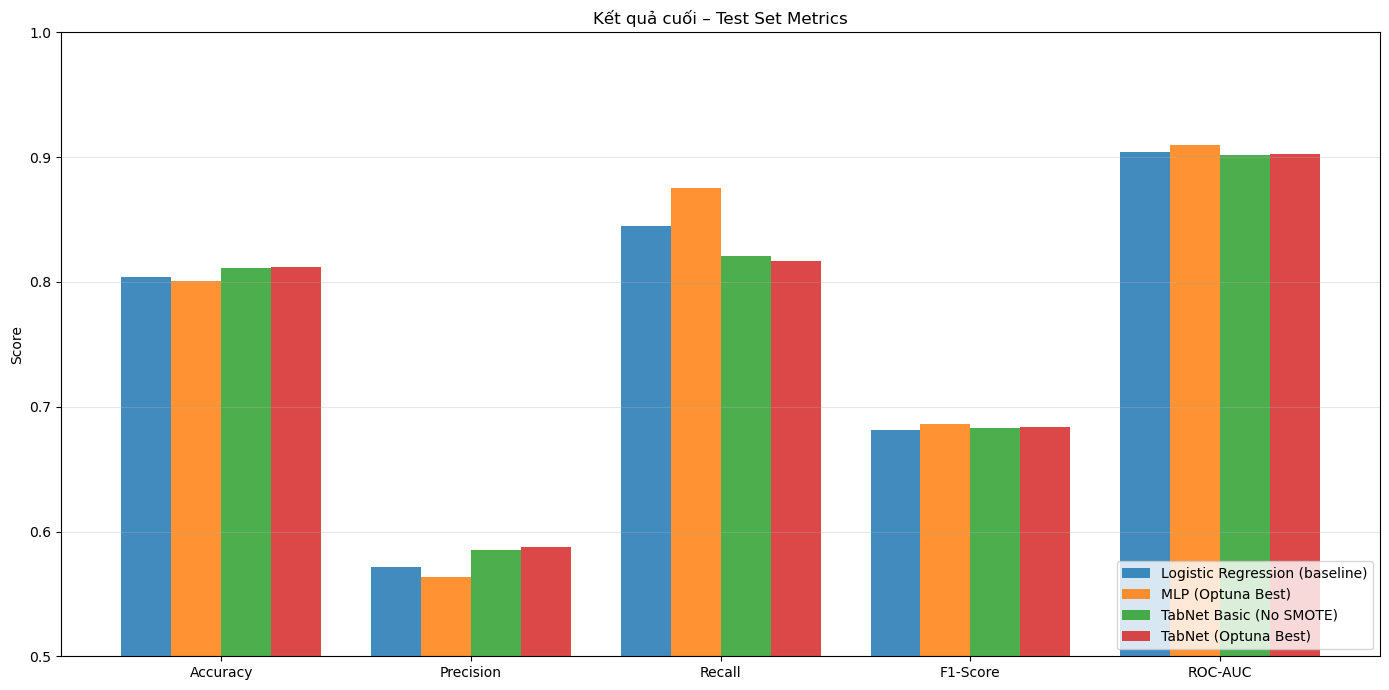

In [76]:
# 7.2 Lấy mô hình có cấu hình tốt nhất và trong tuning_mlp.py
# Hàm `train_best_optuna_tabnet_model` sẽ trả về (model, metrics) nên ta lấy cả hai
best_tabnet_optuna, metrics_tabnet_best = tune.train_best_optuna_tabnet_model(
    study=study_tabnet, 
    prep_tabnet=prep_tabnet, 
    max_epochs=100, 
    patience=15, 
    device=device,
    use_pretraining=True
)

# Để lấy phân loại ROC-AUC, ta dùng predict_proba hoặc chạy lại evaluate
_, y_true_tb, y_pred_tb, y_proba_tb = dl.evaluate_tabnet(best_tabnet_optuna, prep_tabnet)

compare_all.loc['TabNet (Optuna Best)'] = [
    metrics_tabnet_best['accuracy'],
    metrics_tabnet_best['precision'],
    metrics_tabnet_best['recall'],
    metrics_tabnet_best['f1_score'],
    round(roc_auc_score(y_true_tb, y_proba_tb), 4)
]

display(compare_all.style.highlight_max(axis=0, color='lightgreen'))

# Trực quan hoá bản chốt hạ cuối
fig, ax = plt.subplots(figsize=(14, 7))
width_new = 0.2
for i, model_name in enumerate(compare_all.index):
    # Dịch chuyển vị trí các cột
    ax.bar(x + (i - 1.5) * width_new, compare_all.loc[model_name, metrics_to_plot],
           width_new, label=model_name, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('Kết quả cuối – Test Set Metrics')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<!-- @format -->

**Nhận xét:** Trên dữ liệu bảng, các mô hình truyền thống như Logistic Regression vẫn cho hiệu năng rất cạnh tranh và ổn định, gần như ngang với các mô hình deep learning. Mặc dù MLP có cải thiện nhẹ ở một số chỉ số, sự khác biệt không đáng kể và không đủ để khẳng định ưu thế vượt trội. Điều này cho thấy deep learning chỉ thực sự phát huy khi có dữ liệu lớn hoặc cấu trúc phức tạp hơn.


# 8. Lựa chọn và lưu mô hình tốt nhất để triển khai

Sau khi đã huấn luyện, đánh giá các mô hình và so sánh trên bảng `compare_all`. Dựa vào cấu trúc dữ liệu bị mất cân bằng, chỉ số **F1-Score** là thước đo đáng tin cậy để tìm ra mô hình Học sâu xuất sắc nhất.
Mô hình tốt nhất cùng trọng số và bộ tiền xử lý tương ứng sẽ được lưu vào thư mục `models/` nhằm phục vụ cho quá trình inference sau này.

In [47]:
import os
import joblib
import torch

# Tạo thư mục models nếu chưa có
os.makedirs('../models', exist_ok=True)

# 1. So sánh chọn ra mô hình Deep Learning tốt nhất dựa trên ROC-AUC
# Lọc bỏ Logistic Regression (Baseline)
dl_compare = compare_all[compare_all.index != 'Logistic Regression (baseline)']

# Tiêu chí chọn ưu tiên: F1-Score, do dữ liệu mất cân bằng
best_model_name = dl_compare['F1-Score'].idxmax()
best_score = dl_compare.loc[best_model_name, 'F1-Score']

print(f"Mô hình học sâu tốt nhất trong lần chạy này: {best_model_name} với F1-Score = {best_score:.4f}")

# Kiểm tra score kỉ lục đã lưu
score_path = '../models/best_f1_score.txt'
type_path = '../models/best_model_type.txt'
previous_best_score = 0.0

if os.path.exists(score_path):
    with open(score_path, 'r') as f:
        try:
            previous_best_score = float(f.read().strip())
            print(f"Kỉ lục F1-Score trước đó: {previous_best_score:.4f}")
        except ValueError:
            pass

# 2. Xử lý lưu tuỳ thuộc vào việc có phá kỉ lục không
if best_score > previous_best_score:
    print("Lần chạy mô hình này tốt hơn! Tiến hành lưu cấu hình mới...")

    # Ghi nhận kỉ lục mới
    with open(score_path, 'w') as f:
        f.write(str(best_score))
        
    # Lưu loại mô hình (MLP hoặc TabNet) vào text file
    model_type = 'MLP' if 'MLP' in best_model_name else 'TabNet'
    with open(type_path, 'w') as f:
        f.write(model_type)

    if model_type == 'MLP':
        # Nếu MLP là mô hình tốt nhất (Lưu Weights MLP, Scaler, OHE Encoder)
        model_path = '../models/best_dl_model.pth'
        torch.save(best_model_optuna.state_dict(), model_path)
        
        joblib.dump(scaler, '../models/scaler.joblib')
        joblib.dump(ohe_encoder, '../models/ohe_encoder.joblib')
        print(f"Đã lưu trọng số MLP tại: {model_path} cùng bộ tiền xử lý (scaler, ohe_encoder).")

    elif model_type == 'TabNet':
        # Nếu TabNet là mô hình tốt nhất
        # best_tabnet_optuna là đối tượng TabNetClassifier, có hàm save_model()
        model_path = '../models/best_tabnet_model'
        # pytorch_tabnet save model sẽ tự thêm đuôi .zip
        saved_filepath = best_tabnet_optuna.save_model(model_path)
        
        # Kèm theo metadata hoặc configs từ thư viện nếu cần, hoặc pipeline TabNet
        joblib.dump(prep_tabnet, '../models/prep_tabnet.joblib')
        print(f"Đã lưu TabNet tại {saved_filepath} cùng bộ tiền xử lý prep_tabnet.")
else:
    print("Mô hình hiện tại không vượt qua kỉ lục cũ. Bỏ qua bước lưu.")

Mô hình học sâu tốt nhất trong lần chạy này: MLP (Optuna Best) với F1-Score = 0.6881
Lần chạy mô hình này tốt hơn! Tiến hành lưu cấu hình mới...
Đã lưu trọng số MLP tại: ../models/best_dl_model.pth cùng bộ tiền xử lý (scaler, ohe_encoder).
